<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarlo_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q-Learning en CliffWalking-v1**

_Estudio del algoritmo de Diferencia Temporal (TD) Off-Policy_

Este notebook implementa y analiza el algoritmo **Q-Learning** sobre el entorno **CliffWalking-v1** de Gymnasium. A diferencia de los métodos de Monte Carlo, Q-Learning utiliza **bootstrapping**, permitiendo al agente aprender de sus estimaciones actuales sin esperar al final del episodio.

### **Q-Learning**
- **Aprendizaje Off-Policy**: El agente aprende directamente la política óptima $q_*$, independientemente de la política de comportamiento usada para explorar. La acción del target siempre es el $\max$ sobre todas las acciones posibles, no la acción que realmente se tomará después.
- **Diferencia Temporal (TD)**: Actualiza los valores $Q$ basándose en la recompensa inmediata y el máximo valor estimado del siguiente estado:
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)\right]$$
- **Comportamiento en CliffWalking-v1**: Las caídas durante la exploración sí generan actualizaciones negativas en la tabla Q, pero al ser off-policy el target usa `max_a Q(s', a)`. Por eso la política greedy puede converger a la **ruta óptima** (13 pasos por el borde) aunque el comportamiento exploratorio siga siendo arriesgado. En SARSA (on-policy), la política aprendida tiende a ser más conservadora y alejada del acantilado.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de dependencias**: librería `gymnasium`.
- **Importación de librerías**: `numpy`, `matplotlib`, `tqdm`.
- **Creación del entorno CliffWalking-v1**: espacio de observación `Discrete(48)` (grid 4×12), espacio de acciones `Discrete(4)` (arriba, derecha, abajo, izquierda), `render_mode='rgb_array'` para visualización como imagen.
- **Importación de clases del repositorio**: `QLearningAgent`, funciones de visualización.

##### _________ **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [2]:
#@title Importamos librerias
import sys
sys.path.insert(0, '../src')
import os
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import QLearningAgent
from plotting import plot, plot_lengths, print_q_summary, plot_comparison, plot_lengths_comparison, show_greedy_episode

In [3]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

# Fijar la semilla en NumPy
np.random.seed(SEED)
np.random.default_rng(SEED)

# Fijar la semilla en Python (evita variabilidad en hashing)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


In [4]:
#@title Importamos el entorno CliffWalking-v1
env = gym.make('CliffWalking-v1', render_mode='rgb_array')
env.reset(seed=SEED)   # Fija la semilla del entorno (patrón sección 5.4 del PDF)

nS = env.observation_space.n  # 48
nA = env.action_space.n       # 4
print(f"Estados: {nS}, Acciones: {nA}")
print(f"Recompensas: -1 por paso | -100 caída al acantilado | 0 al llegar")
print()


Estados: 48, Acciones: 4
Recompensas: -1 por paso | -100 caída al acantilado | 0 al llegar



## **2. Diseño del Agente**

El diseño del agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### **Política Epsilon-Greedy**
- El agente utiliza una política **$\epsilon$-soft** para garantizar la exploración continua del espacio de estados.
- Con probabilidad $1-\varepsilon$, selecciona la acción con el mayor valor $Q$ (explotación).
- Con probabilidad $\varepsilon$, selecciona una acción al azar (exploración).

### **Algoritmo Q-Learning**
- Implementado en la clase `QLearningAgent`, este algoritmo actualiza la tabla $Q$ en cada paso del entorno.
- A diferencia de SARSA,  Q-Learning es off-policy porque su target usa siempre `max_a Q(S', a)` independientemente de la acción que realmente tomará el agente. Recordemos:
 $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)\right]$$

In [5]:

UP, RIGHT, DOWN, LEFT = 0,1,2,3
ACTION_NAMES = {0: 'N↑', 1: 'E→', 2: 'S↓', 3: 'W←', 4: 'PU', 5: 'DO'}
# La política greedy se obtiene con agent.pi_star(seed=SEED, action_names=ACTION_NAMES)

## **3. Experimentación**

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Recompensa media acumulada**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$. En CliffWalking-v1 las recompensas son negativas (-1 por paso, -100 por caer al acantilado). Como esta métrica es acumulada, si el agente cae con frecuencia al acantilado durante muchos episodios, el promedio puede estabilizarse en valores muy por debajo de -13, aunque la política greedy final sea óptima.

**Gráfica 2 — Longitud de los episodios**: Mide cuántos pasos tarda el agente en llegar al objetivo o caer al acantilado.
1. **Inicio**: Episodios muy largos y frecuentes caídas al acantilado (penalización -100 y reset al inicio).
2. **Aprendizaje**: La longitud se estabiliza a medida que el agente aprende a navegar hacia el objetivo.
3. **Convergencia**: Las configuraciones que aprenden tienden a episodios cortos; en este experimento la estándar se estabiliza ~17 pasos, mientras que $\epsilon=0.01$ se acerca a ~13 pasos (ruta óptima).

**Función `show_greedy_episode`**: Permite observar el comportamiento final del agente sin exploración, verificando si ha aprendido a cruzar el grid sin caer al acantilado y llegar al objetivo en el menor número de pasos posible.

### **3.2 Q-Learning en CliffWalking-v1**

Se entrenan **10 000 episodios** con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\ 1000/(t+1))$.

El decaimiento es necesario porque:
- Al inicio, $\varepsilon$ alto favorece exploración amplia del grid, incluyendo zonas cercanas al acantilado.
- Al final, $\varepsilon \to 0$ hace que el agente explote la política aprendida, navegando directamente al objetivo.

Al ser off-policy, el decaimiento de $\varepsilon$ solo afecta a la política de comportamiento (la exploración), no al target de aprendizaje. Las caídas durante la exploración sí generan actualizaciones negativas, pero el target usa la mejor acción estimada; por eso la política greedy puede converger a la ruta óptima a pesar de un comportamiento exploratorio arriesgado.

La semilla numpy fija (`SEED = 2024`) garantiza reproducibilidad.

In [6]:
# @title Aprendizaje off-policy (baseline)
agent_Q = QLearningAgent(env, epsilon=1, alpha=0.1, discount_factor=0.99, decay=True)
agent_Q.train(num_episodes=10000)
list_stats_Q, list_lengths_Q = agent_Q.stats()
Q_Q = agent_Q.q_values

  0%|          | 0/10000 [00:00<?, ?it/s]

 10%|█         | 1002/10000 [01:20<11:34, 12.96it/s]

success: -64713.5700, epsilon: 1.0000


 24%|██▍       | 2383/10000 [01:25<00:04, 1627.66it/s]

success: -33871.7265, epsilon: 0.5000


...

success: -8543.7229, epsilon: 0.1250


 95%|█████████▍| 9481/10000 [01:27<00:00, 4410.22it/s]

success: -7600.0029, epsilon: 0.1111


100%|██████████| 10000/10000 [01:27<00:00, 114.75it/s]

success: -6845.2253, epsilon: 0.1000


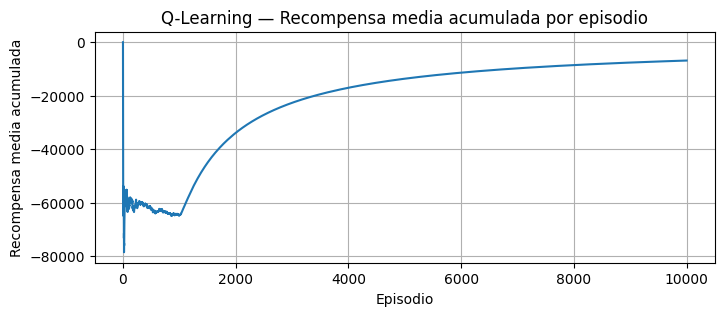

Recompensa media final: -6845.23


In [7]:
#@title Recompensa media acumulada por episodio (off-policy)
plot(list_stats_Q, title='Q-Learning — Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada')
print(f'Recompensa media final: {list_stats_Q[-1]:.2f}')

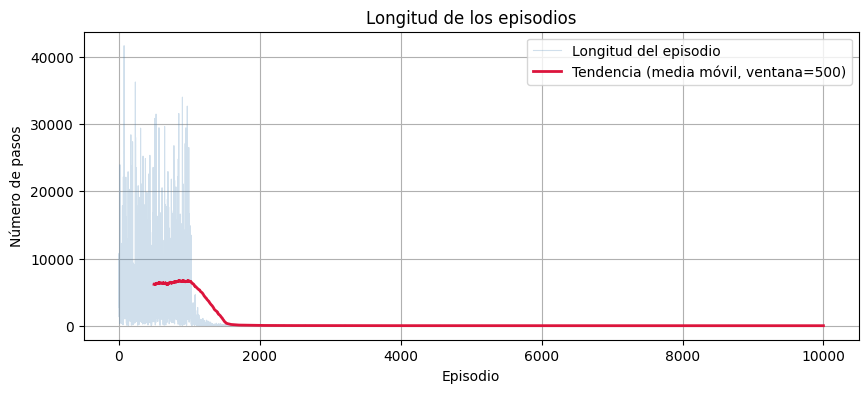

Longitud media final (últimos 1000 episodios): 17.08 pasos


In [8]:
#@title Longitud de episodios (off-policy)
plot_lengths(list_lengths_Q)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths_Q[-1000:]):.2f} pasos')

#### Resumen estadístico de la tabla Q aprendida. Con 48 estados y 4 acciones la tabla tiene 192 entradas.
Se muestran estadísticas globales para verificar que el agente ha aprendido valores coherentes. En CliffWalking-v1 todos los valores Q son negativos o cero, ya que no existe ninguna recompensa positiva en el entorno — solo penalizaciones (-1 por paso, -100 por caída).

In [9]:
# @title Resumen tabla Q — off-policy
print_q_summary(env, Q_Q, title="Off-Policy — Tabla Q")

--- Off-Policy — Tabla Q ---
  Entradas no nulas : 148/192 (77.1%)
  Max Q             : 0.000
  Min Q (no nulo)   : -112.125
  Q media (no nulo) : -16.015


Se muestra la política greedy obtenida. `agent.pi_star(seed, action_names)` sigue `argmax Q[s]` desde el estado inicial (esquina inferior izquierda, estado 36) y devuelve la secuencia de acciones en formato legible (N↑ E→ S↓ W←). También se ejecuta `show_greedy_episode` para verificar visualmente la ruta aprendida.

In [10]:
# @title Política final (off-policy)
pi, actions = agent_Q.pi_star(seed=SEED, action_names=ACTION_NAMES)
print("Política greedy obtenida (off-policy)")
print(f"Acciones: {actions}")
print()
show_greedy_episode(env, Q_Q, seed=SEED, title="Q-learning — Episodio greedy")

Política greedy obtenida (off-policy)
Acciones: N↑ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → E→ → S↓

Q-learning — Episodio greedy  |  Recompensa: -13  |  Pasos: 13  |  Terminado

Estado inicial:
[[[ 91 150  97]
  [ 91 150  97]
  [ 91 150  97]
  ...
  [ 86 170  69]
  [ 86 170  69]
  [ 86 170  69]]

 [[ 91 150  97]
  [ 91 150  97]
  [ 91 150  97]
  ...
  [ 86 170  69]
  [ 86 170  69]
  [ 86 170  69]]

 [[ 91 150  97]
  [ 91 150  97]
  [ 98 166 105]
  ...
  [105 182  74]
  [105 182  74]
  [ 86 170  69]]

 ...

 [[ 86 170  69]
  [ 86 170  69]
  [ 93 188  74]
  ...
  [ 91 150  97]
  [ 91 150  97]
  [ 91 150  97]]

 [[ 86 170  69]
  [ 86 170  69]
  [ 93 188  74]
  ...
  [ 91 150  97]
  [ 91 150  97]
  [ 91 150  97]]

 [[ 86 170  69]
  [ 86 170  69]
  [ 86 170  69]
  ...
  [ 91 150  97]
  [ 91 150  97]
  [ 91 150  97]]]
Estado final:
[[[ 91 150  97]
  [ 91 150  97]
  [ 91 150  97]
  ...
  [ 86 170  69]
  [ 86 170  69]
  [ 86 170  69]]

 [[ 91 150  97]
  [ 91 150  97]
  [ 91 150  97

### **3.3 Modificación de parámetros de Q-learning**

Los hiperparámetros en el algoritmo Q-Learning son fundamentales para equilibrar la explotación versus la exploración y cómo se gestionan las nuevas experiencias.

- La tasa de aprendizaje ($\alpha$) controla qué tan rápido el agente actualiza sus valores Q ante nueva información; un valor elevado puede acelerar la convergencia inicial pero generar inestabilidad, mientras que un valor bajo asegura una convergencia más suave y robusta.
- El parámetro épsilon ($\epsilon$) determina el grado de exploración del grid. En CliffWalking-v1, una exploración alta inicial expone al agente a frecuentes caídas al acantilado (-100), lo que deprime el promedio acumulado pero permite descubrir rutas. Al ser Q-Learning off-policy, estas caídas no contaminan el target de aprendizaje.
- El factor de descuento ($\gamma$) dicta la importancia de las recompensas futuras frente a las inmediatas; un $\gamma$ cercano a 1.0 es vital para que el agente planifique rutas largas hacia el objetivo, ya que todas las recompensas intermedias son -1 y solo el final del episodio termina la penalización acumulada.

In [11]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=0.01, alpha=0.1, discount_factor=0.99, decay=False)
agent_Q.train(num_episodes=10000)
list_stats_Q_epsilon, list_lengths_Q_epsilon = agent_Q.stats()
Q_Q = agent_Q.q_values

 16%|█▌        | 1617/10000 [00:00<00:01, 4664.34it/s]

success: -25.9540, epsilon: 0.0100
success: -20.6330, epsilon: 0.0100


 39%|███▉      | 3931/10000 [00:00<00:01, 5579.25it/s]

success: -19.1330, epsilon: 0.0100
success: -18.3798, epsilon: 0.0100


 57%|█████▋    | 5653/10000 [00:01<00:00, 5694.00it/s]

success: -17.9746, epsilon: 0.0100
success: -17.5890, epsilon: 0.0100


 80%|███████▉  | 7951/10000 [00:01<00:00, 5603.02it/s]

success: -17.4913, epsilon: 0.0100
success: -17.4352, epsilon: 0.0100


100%|██████████| 10000/10000 [00:01<00:00, 5344.47it/s]

success: -17.3196, epsilon: 0.0100
success: -17.1807, epsilon: 0.0100


In [12]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=1, alpha=0.5, discount_factor=0.99, decay=True)
agent_Q.train(num_episodes=10000)
list_stats_Q_alpha, list_lengths_Q_alpha = agent_Q.stats()
Q_Q = agent_Q.q_values

 10%|█         | 1001/10000 [01:21<09:47, 15.30it/s]

success: -65978.1170, epsilon: 1.0000


 24%|██▍       | 2396/10000 [01:26<00:04, 1613.00it/s]

success: -34832.5825, epsilon: 0.5000


 35%|███▍      | 3473/10000 [01:26<00:02, 2499.59it/s]

...

success: -8784.1606, epsilon: 0.1250


 99%|█████████▊| 9870/10000 [01:28<00:00, 4413.67it/s]

success: -7813.9047, epsilon: 0.1111


100%|██████████| 10000/10000 [01:28<00:00, 112.83it/s]

success: -7037.7481, epsilon: 0.1000


In [13]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=1, alpha=0.1, discount_factor=0.25, decay=True)
agent_Q.train(num_episodes=10000)
list_stats_Q_discount, list_lengths_Q_discount = agent_Q.stats()
Q_Q = agent_Q.q_values

 10%|█         | 1002/10000 [01:19<10:32, 14.22it/s]

success: -64291.1370, epsilon: 1.0000


 22%|██▏       | 2199/10000 [01:24<00:05, 1428.79it/s]

success: -33960.7805, epsilon: 0.5000


 35%|███▍      | 3452/10000 [01:25<00:02, 2436.05it/s]

...

success: -8566.3175, epsilon: 0.1250


 99%|█████████▉| 9882/10000 [01:26<00:00, 4486.03it/s]

success: -7620.4901, epsilon: 0.1111


100%|██████████| 10000/10000 [01:26<00:00, 115.11it/s]

success: -6863.0571, epsilon: 0.1000


In [14]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=1, alpha=0.1, discount_factor=0.05, decay=True)
agent_Q.train(num_episodes=10000)
list_stats_Q_bigdiscount, list_lengths_Q_bigdiscount = agent_Q.stats()
Q_Q = agent_Q.q_values

 10%|█         | 1001/10000 [01:20<09:31, 15.73it/s]

success: -65234.7330, epsilon: 1.0000


 21%|██        | 2093/10000 [01:26<00:09, 796.38it/s]

success: -34316.6760, epsilon: 0.5000


 31%|███       | 3105/10000 [01:27<00:07, 980.41it/s]

...

success: -8680.7624, epsilon: 0.1250


 91%|█████████ | 9098/10000 [01:36<00:01, 470.92it/s]

success: -7735.4584, epsilon: 0.1111


100%|██████████| 10000/10000 [01:39<00:00, 100.93it/s]

success: -6980.9861, epsilon: 0.1000


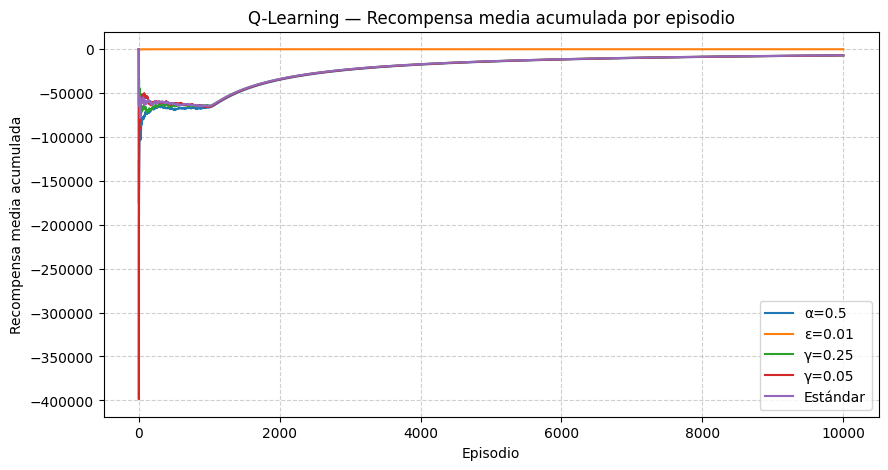

Recompensa media final de α=0.5: -7037.75
Recompensa media final de ε=0.01: -17.18
Recompensa media final de γ=0.25: -6863.06
Recompensa media final de γ=0.05: -6980.99
Recompensa media final de Estándar: -6845.23


In [15]:
#@title Recompensa media acumulada por episodio (off-policy)
lista_plots_recompensa = [list_stats_Q_alpha, list_stats_Q_epsilon, list_stats_Q_discount, list_stats_Q_bigdiscount, list_stats_Q]
labels = ['α=0.5', 'ε=0.01', 'γ=0.25', 'γ=0.05', 'Estándar']
plot_comparison(lista_plots_recompensa, title='Q-Learning — Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada', labels=labels)
for lista, label in zip(lista_plots_recompensa, labels):
    print(f'Recompensa media final de {label}: {lista[-1]:.2f}')

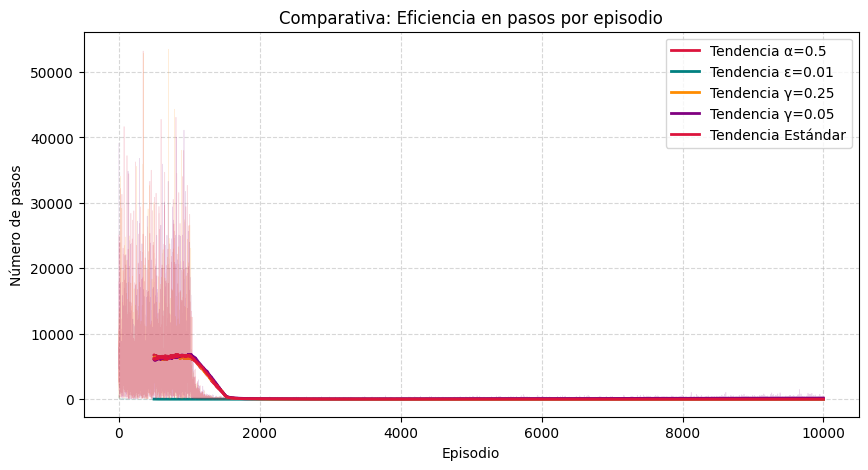

Longitud media final (últimos 1000 episodios) de α=0.5: 17.19 pasos
Longitud media final (últimos 1000 episodios) de ε=0.01: 13.36 pasos
Longitud media final (últimos 1000 episodios) de γ=0.25: 16.66 pasos
Longitud media final (últimos 1000 episodios) de γ=0.05: 184.70 pasos
Longitud media final (últimos 1000 episodios) de Estándar: 17.08 pasos


In [16]:
#@title Longitud de episodios (off-policy)
lista_plots_longitud = [list_lengths_Q_alpha, list_lengths_Q_epsilon, list_lengths_Q_discount, list_lengths_Q_bigdiscount, list_lengths_Q]
plot_lengths_comparison(lista_plots_longitud, labels=labels)
for lista, label in zip(lista_plots_longitud, labels):
    print(f'Longitud media final (últimos 1000 episodios) de {label}: {np.mean(lista[-1000:]):.2f} pasos')

### **3.3.1 Análisis de los hiperparámetros**

### **3.3.1 Análisis de Resultados y Comparación de Configuraciones**

En esta sección se evalúa el impacto de los hiperparámetros en el aprendizaje de Q-Learning en CliffWalking-v1. Se han definido cuatro configuraciones específicas (más la original):

1. **Configuración 1 ($\epsilon=0.01$)** sin decaimiento: Minimiza la exploración desde el inicio. En CliffWalking-v1 esto es especialmente efectivo porque el agente evita las caídas al acantilado desde el principio, aprendiendo rápidamente una política útil.
2. **Configuración 2 ($\alpha=0.5$)**: Dobla la tasa de aprendizaje, permitiendo actualizaciones más rápidas. En este experimento no muestra una mejora claramente superior frente a la configuración estándar.
3. **Configuración 3 ($\gamma=0.25$)**: Reduce el descuento de recompensas futuras. En este experimento sigue permitiendo aprender una política funcional, pero no muestra ventaja clara frente a la configuración estándar y queda por detrás de $\epsilon=0.01$.
4. **Configuración 4 ($\gamma=0.05$)**: Descuento extremo. El aprendizaje es deficiente: episodios muy largos y recompensa media muy negativa.

#### **Interpretación de las Gráficas**

**Recompensa Media Acumulada**:
- La configuración estándar (con decaimiento desde $\epsilon=1$) muestra un promedio muy negativo dominado por las frecuentes caídas al acantilado durante los primeros episodios de exploración aleatoria.
- **$\epsilon=0.01$** es claramente la mejor configuración: al evitar la exploración masiva inicial, el promedio acumulado no se ve arrastrado por cientos de episodios con penalización de -100.
- $\gamma=0.25$ no muestra mejora frente a la estándar, y $\gamma=0.05$ tiene un rendimiento claramente deficiente.

**Longitud de los Episodios**:
- Las configuraciones que aprenden una política útil convergen a episodios relativamente cortos, mientras que $\gamma=0.05$ no lo hace.
- Las diferencias en longitud final entre las configuraciones que sí aprenden no son enormes, pero $\epsilon=0.01$ es la que más se aproxima a la ruta óptima de 13 pasos.

### **Guardar métricas (Q-Learning)**

Esta celda guarda las series para poder comparar con otros notebooks.


In [17]:
import os, numpy as np
os.makedirs('metrics', exist_ok=True)
np.savez('metrics/q_cliff.npz', list_stats=list_stats_Q, list_lengths=list_lengths_Q)
print('Guardado: metrics/q_cliff.npz')


Guardado: metrics/q_cliff.npz


### **Comentario de la comparativa Q‑Learning vs SARSA**

- La **recompensa media acumulada** es muy negativa al inicio porque la métrica arrastra muchas caídas (-100) en las primeras fases de exploración.
- A medida que avanza el entrenamiento, **Q‑Learning queda ligeramente por encima (menos negativo)** que SARSA, indicando mejor desempeño promedio acumulado.
- La separación entre curvas es moderada: ambos mejoran, pero el off‑policy de Q‑Learning se beneficia de un target greedy.
- Esta gráfica es acumulada; para validar la ruta óptima conviene mirar también el **episodio greedy final** (13 pasos, recompensa -13).


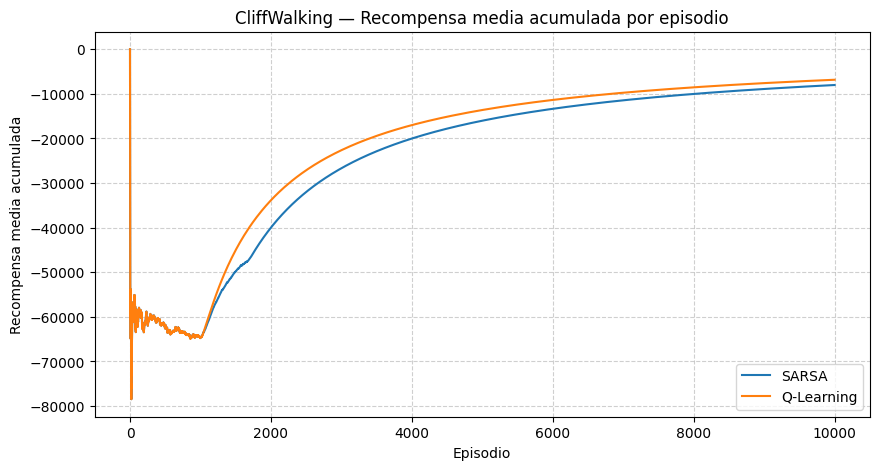

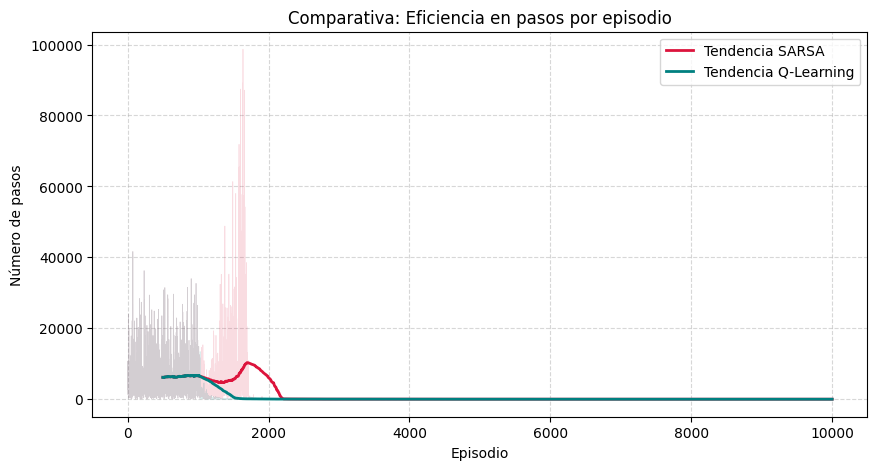

SARSA      — Recompensa media final: -8025.64
Q-Learning — Recompensa media final: -6845.23
SARSA      — Longitud media final (últimos 1000 ep.): 19.33 pasos
Q-Learning — Longitud media final (últimos 1000 ep.): 17.08 pasos


In [6]:
from pathlib import Path
import numpy as np

def _load_metrics(path):
    data = np.load(path, allow_pickle=True)
    return data['list_stats'], data['list_lengths']

q_path = Path("metrics/q_cliff.npz")
s_path = Path("metrics/sarsa_cliff.npz")

if not (q_path.exists() and s_path.exists()):
    raise FileNotFoundError("Faltan metrics/q_cliff.npz o metrics/sarsa_cliff.npz")

list_stats_Q, list_lengths_Q = _load_metrics(q_path)
list_stats_S, list_lengths_S = _load_metrics(s_path)

LABELS = ["SARSA", "Q-Learning"]

plot_comparison(
    [list_stats_S, list_stats_Q],
    labels=LABELS,
    title="CliffWalking — Recompensa media acumulada por episodio",
    ylabel="Recompensa media acumulada"
)

plot_lengths_comparison(
    [list_lengths_S, list_lengths_Q],
    labels=LABELS
)

for stats, label in zip([list_stats_S, list_stats_Q], LABELS):
    print(f"{label:10s} — Recompensa media final: {stats[-1]:.2f}")
for lengths, label in zip([list_lengths_S, list_lengths_Q], LABELS):
    print(f"{label:10s} — Longitud media final (últimos 1000 ep.): {np.mean(lengths[-1000:]):.2f} pasos")
